# Maths Lab B — Detection Theory & Matched Filtering

*An appendix lab for the `jansky` course. Prerequisite reading:*
[*Mathematical Preliminaries* §5 (Probability & statistics for noise)](../docs/math-preliminaries.md)
*and §8 (special functions).*

Most of this course has been about **measuring** things — a flux density, a
spectral index, an image. This lab is about a prior, sharper question that sits
underneath all of them:

> **Is there a signal in this noise at all — and how sure are we?**

That is the problem of **detection theory**, and its central result is the
**matched filter**: when you know the *shape* of the thing you are looking for,
the optimal way to find it in white Gaussian noise is to **correlate the data
with a copy of that shape**. This one idea unifies three searches you have
already met as if they were unrelated:

- the **boxcar width search** for fast radio bursts ([Chapter 18](18_fast_radio_bursts.ipynb)),
- the **dispersion-measure search** that de-disperses along $\nu^{-2}$ tracks (also Ch 18), and
- the **Doppler-drift search** for technosignatures along sloped lines ([Chapter 21](21_seti.ipynb)).

All three are the *same* operation — matched filtering — applied to a different
template. By the end of this lab you will see why.

### Learning goals

By the end you will be able to:

- state the detection problem as a choice between two hypotheses, $H_0$ (noise
  only) versus $H_1$ (signal present);
- **derive** why correlating with the known template is the optimal linear
  detector in white Gaussian noise, and show it numerically;
- explain the matched-filter S/N gain $\propto \sqrt{N}$ and watch a buried pulse
  emerge from noise;
- use `jansky.transients.boxcar_snr` to show a boxcar matched to the pulse width
  maximises S/N;
- see **dedispersion** (`dm_search`) and the **drift search** (`drift_search`) as
  one unifying idea — matched filtering along a curve;
- compute a **ROC curve** by Monte Carlo, and reason about the **"5σ"** convention
  and the **trials factor**.

This lab runs **end-to-end offline** on the base environment: just `numpy`,
`scipy`, `matplotlib`, and `jansky`.

## 1. Orientation — the question "is there a signal in this noise?"

A radio telescope mostly measures **noise**. Thermal noise from the receiver and
the sky is, to excellent approximation, **Gaussian** — the central-limit shape of
[*Maths Preliminaries* §5](../docs/math-preliminaries.md). Against that hiss, the
thing you want — a pulse, a tone, a faint source — is often *far below* the
noise in any single sample. Detection is therefore a **statistical** decision,
not a measurement you can just read off.

Frame it as a choice between two **hypotheses** about a data vector $\mathbf{x}$
of $N$ samples:

$$
H_0:\quad \mathbf{x} = \mathbf{n}
\qquad\text{(noise only)}
$$
$$
H_1:\quad \mathbf{x} = a\,\mathbf{s} + \mathbf{n}
\qquad\text{(a signal of known shape } \mathbf{s}\text{, unknown amplitude } a>0\text{, plus noise)}
$$

with $\mathbf{n}$ white Gaussian noise: each $n_i \sim \mathcal{N}(0,\sigma^2)$,
independent. We *know the shape* $\mathbf{s}$ (the template) but not whether it
is there, nor how strong. We compute some **statistic** $T(\mathbf{x})$, compare
it to a **threshold** $\gamma$, and declare a detection if $T > \gamma$.

Two questions follow, and they are the whole subject:

1. **What statistic $T$ is best?** (Section 2: the matched filter.)
2. **Where do we put the threshold $\gamma$?** (Section 5: ROC curves and "5σ".)

The signal-to-noise ratio from §5, $\mathrm{SNR}=\text{signal}/\sigma_\text{noise}$,
is the quantity a good statistic maximises. Let us first see the problem with our
own eyes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

from jansky.plotting import use_jansky_style
from jansky.transients import boxcar_snr, disperse_pulse, dedisperse, dm_search, dispersion_delay
from jansky.seti import drifting_tone, drift_search

use_jansky_style()
rng = np.random.default_rng(32)  # one seed for the whole lab

print("Maths Lab B set up. NumPy", np.__version__)

Maths Lab B set up. NumPy 2.4.6


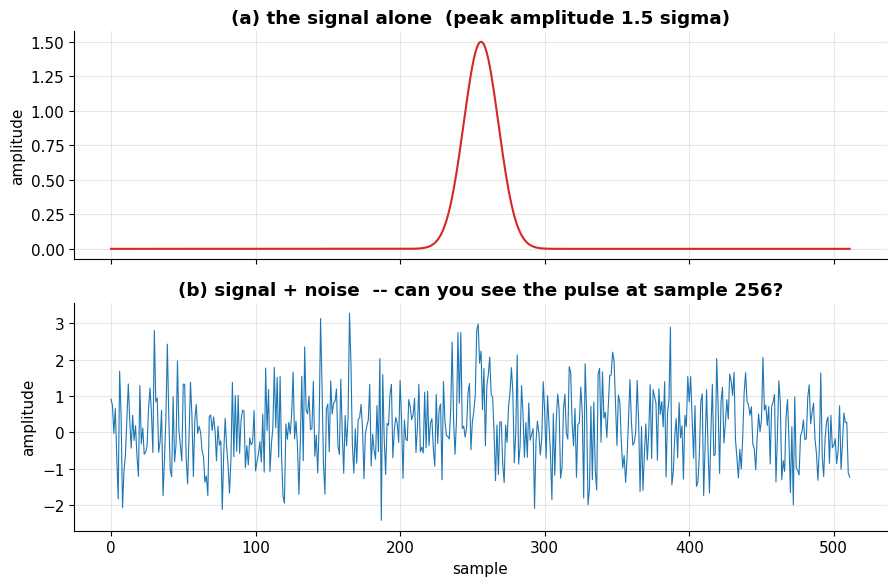

Per-sample peak SNR is only 1.5 -- lost among the noise spikes by eye.
But the template spans ||s||^2 = 21 samples' worth of signal.


In [2]:
# A known pulse shape buried in white Gaussian noise.
N = 512
t = np.arange(N)
sigma = 1.0                       # noise std
amp_true = 1.5                    # peak signal amplitude -- ~1.5 sigma per sample
centre, width = 256, 12.0         # a broad-ish Gaussian: many samples carry the signal
template = np.exp(-0.5 * ((t - centre) / width) ** 2)   # unit-peak Gaussian pulse

noise = rng.normal(0.0, sigma, size=N)
x = amp_true * template + noise   # H1: signal present

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t, amp_true * template, color="#d62728")
axes[0].set_title(f"(a) the signal alone  (peak amplitude {amp_true} sigma)")
axes[0].set_ylabel("amplitude")
axes[1].plot(t, x, color="#1f77b4", lw=0.8)
axes[1].set_title("(b) signal + noise  -- can you see the pulse at sample 256?")
axes[1].set_xlabel("sample"); axes[1].set_ylabel("amplitude")
fig.tight_layout()
plt.show()

print(f"Per-sample peak SNR is only {amp_true/sigma:.1f} -- lost among the noise spikes by eye.")
print(f"But the template spans ||s||^2 = {np.sum(template**2):.0f} samples' worth of signal.")

The pulse in panel (b) is *invisible*: its peak barely pokes above the noise, and
several noise spikes are taller. Yet there are about a dozen samples that all lean
the same way, and that redundancy is exactly what a matched filter exploits. We
turn to it now.

## 2. The matched filter — the optimal linear detector

### The claim

Among all **linear** statistics — anything of the form $T = \sum_i w_i x_i =
\mathbf{w}\cdot\mathbf{x}$, a weighted sum of the samples — the one that maximises
the output signal-to-noise ratio in white Gaussian noise is the one whose weights
**are the template itself**:

$$
\boxed{\;\mathbf{w} \propto \mathbf{s}\;}
\qquad\Longrightarrow\qquad
T = \mathbf{s}\cdot\mathbf{x} = \sum_i s_i\,x_i .
$$

That is: *correlate the data with a copy of the signal you are looking for.* This
is the **matched filter**.

### Why — a two-line derivation

Take any weight vector $\mathbf{w}$ and feed it the two hypotheses.

- **Signal part.** Under $H_1$ the expected output is
  $\langle T\rangle = a\,(\mathbf{w}\cdot\mathbf{s})$.
- **Noise part.** Because the noise is white ($\langle n_i n_j\rangle =
  \sigma^2\delta_{ij}$), the output variance is
  $\operatorname{Var}(T) = \sigma^2\,(\mathbf{w}\cdot\mathbf{w}) = \sigma^2|\mathbf{w}|^2$.

So the output signal-to-noise ratio is

$$
\mathrm{SNR}_\text{out}
= \frac{\langle T\rangle}{\sqrt{\operatorname{Var}(T)}}
= \frac{a\,(\mathbf{w}\cdot\mathbf{s})}{\sigma\,|\mathbf{w}|}
= \frac{a}{\sigma}\,|\mathbf{s}|\,\cos\theta,
$$

where $\theta$ is the angle between $\mathbf{w}$ and $\mathbf{s}$ (the last step is
just the dot-product identity from [*Maths Prelims* §9](../docs/math-preliminaries.md)).
This is maximised when $\cos\theta = 1$, i.e. when **$\mathbf{w}$ points along
$\mathbf{s}$**. Any other filter — pointed even slightly off — measures less of the
signal and the same noise, and loses S/N. That is the whole theorem: it is just
the Cauchy–Schwarz inequality wearing a lab coat. (This is the white-noise case;
for *coloured* noise one first "whitens" the data, which is why the general result
is $\mathbf{w}\propto \mathbf{C}^{-1}\mathbf{s}$ with $\mathbf{C}$ the noise
covariance.)

### The peak S/N

Plugging $\mathbf{w}=\mathbf{s}$ back in, the matched filter delivers

$$
\mathrm{SNR}_\text{out} = \frac{a}{\sigma}\,|\mathbf{s}|
= \frac{a}{\sigma}\sqrt{\textstyle\sum_i s_i^2}.
$$

For a flat-topped (boxcar) pulse of height $a$ spread over $N_\text{pulse}$
samples, $|\mathbf{s}| = \sqrt{N_\text{pulse}}$, so

$$
\mathrm{SNR}_\text{out} = \frac{a}{\sigma}\sqrt{N_\text{pulse}}.
$$

**The S/N grows as $\sqrt{N_\text{pulse}}$** — the same $1/\sqrt{N}$ averaging law
from §5, read forwards. A pulse invisible in one sample becomes a confident
detection once you coherently add up all the samples it occupies. Let us watch it
happen.

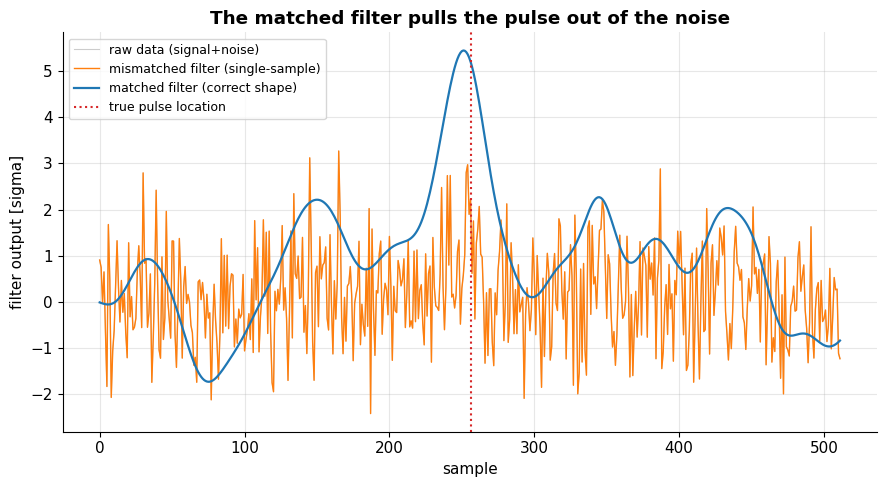

Matched-filter peak S/N    : 5.45
Mismatched-filter peak S/N : 3.27


In [3]:
# Matched filter = correlate the data with a copy of the template.
# (Sliding correlation: try the template at every lag.)
def matched_filter(data, templ):
    templ = templ / np.linalg.norm(templ)          # unit-norm -> output is in sigma units
    return np.correlate(data, templ, mode="same")

mf = matched_filter(x, template)

# A MISMATCHED filter: same energy, wrong shape (a narrow spike).
wrong = np.zeros_like(template); wrong[centre] = 1.0
mf_wrong = matched_filter(x, wrong)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t, x, color="#cccccc", lw=0.8, label="raw data (signal+noise)")
ax.plot(t, mf_wrong, color="#ff7f0e", lw=1.0, label="mismatched filter (single-sample)")
ax.plot(t, mf, color="#1f77b4", lw=1.6, label="matched filter (correct shape)")
ax.axvline(centre, color="#d62728", ls=":", label="true pulse location")
ax.set_xlabel("sample"); ax.set_ylabel("filter output [sigma]")
ax.set_title("The matched filter pulls the pulse out of the noise")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout(); plt.show()

print(f"Matched-filter peak S/N    : {mf.max():.2f}")
print(f"Mismatched-filter peak S/N : {mf_wrong.max():.2f}")

The matched filter (blue) produces a clean peak at the true location, towering
over the noise; the mismatched single-sample filter (orange) is barely better than
the raw data. Same data, same noise — the only difference is whether the filter
*knows the shape*.

Now the headline scaling: sweep the pulse width and confirm
$\mathrm{SNR}\propto\sqrt{N_\text{pulse}}$.

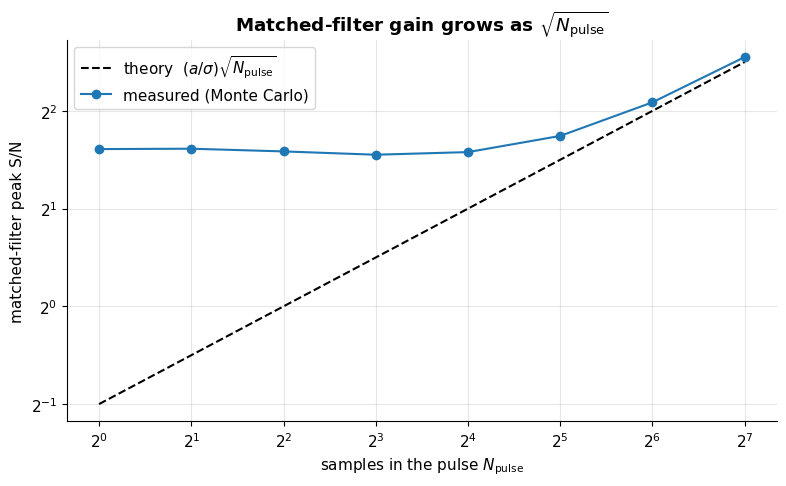

width   measured   theory
    1      3.05     0.50
    2      3.06     0.71
    4      3.00     1.00
    8      2.93     1.41
   16      2.99     2.00
   32      3.35     2.83
   64      4.25     4.00
  128      5.86     5.66


In [4]:
# S/N gain vs number of samples in the pulse. Use flat-top (boxcar) pulses so the
# theory line sqrt(N) is exact. Average over many noise realisations.
widths_px = np.array([1, 2, 4, 8, 16, 32, 64, 128])
a, sig = 0.5, 1.0          # weak per-sample signal
n_real = 400

measured = []
for w in widths_px:
    box = np.zeros(N); box[centre - w // 2: centre - w // 2 + w] = 1.0  # unit-height boxcar
    snrs = []
    for _ in range(n_real):
        d = a * box + rng.normal(0, sig, N)
        snrs.append(matched_filter(d, box).max())
    measured.append(np.mean(snrs))
measured = np.array(measured)

theory = (a / sig) * np.sqrt(widths_px)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(widths_px, theory, "k--", label=r"theory  $(a/\sigma)\sqrt{N_{\rm pulse}}$")
ax.plot(widths_px, measured, "o-", color="#1f77b4", label="measured (Monte Carlo)")
ax.set_xscale("log", base=2); ax.set_yscale("log", base=2)
ax.set_xlabel(r"samples in the pulse $N_{\rm pulse}$")
ax.set_ylabel("matched-filter peak S/N")
ax.set_title(r"Matched-filter gain grows as $\sqrt{N_{\rm pulse}}$")
ax.legend()
fig.tight_layout(); plt.show()

print("width   measured   theory")
for w, m, th in zip(widths_px, measured, theory):
    print(f"{w:5d}   {m:7.2f}   {th:6.2f}")

The measured points sit right on the $\sqrt{N_\text{pulse}}$ line (slope $1/2$ on
log–log axes). A pulse that is a feeble $0.5\sigma$ per sample becomes a $\sim
5.6\sigma$ detection once it is 128 samples wide and we add it up coherently.
That is the entire reason matched filtering matters: **it converts width into
significance.**

## 3. Boxcars & templates — the FRB width search

In real transient searches the pulse width is **unknown**, so you cannot pick the
perfectly matched template in advance. The practical compromise — used in PRESTO,
`turboSETI`, and every FRB pipeline — is a **bank of boxcar filters** of different
widths. You run them all and keep the best. A boxcar of width $w$ is the matched
filter for a *top-hat* pulse $w$ samples wide; matched to the true width it
maximises S/N, too narrow throws away signal, too wide adds noise without signal.

`jansky.transients.boxcar_snr` is exactly this bank: it convolves the series with
unit-energy boxcars $\mathbf{1}/\sqrt{w}$ (the $1/\sqrt{w}$ keeps white-noise
$\sigma$ fixed, so outputs are directly in S/N units) and returns the best width.
This is the engine behind the FRB width search in
[Chapter 18 §4](18_fast_radio_bursts.ipynb).

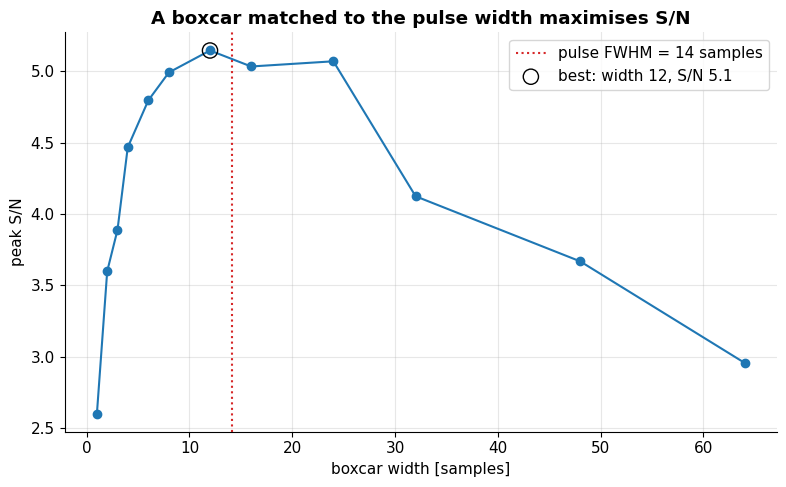

Best boxcar width = 12 samples (pulse FWHM ~ 14), S/N = 5.15


In [5]:
# A single Gaussian pulse of known width, buried in noise.
pulse_width = 6.0
pulse_amp = 2.0   # bright enough that the matched width wins over noise fluctuations
series = pulse_amp * np.exp(-0.5 * ((t - centre) / pulse_width) ** 2) + rng.normal(0, 1.0, N)

trial_widths = np.array([1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64])
snr_by_width = []
for w in trial_widths:
    best_snr, best_w, peak = boxcar_snr(series, np.array([w]))
    snr_by_width.append(best_snr)
snr_by_width = np.array(snr_by_width)

best_snr, best_w, peak = boxcar_snr(series, trial_widths)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(trial_widths, snr_by_width, "o-", color="#1f77b4")
ax.axvline(2.355 * pulse_width, color="#d62728", ls=":",
           label=f"pulse FWHM = {2.355*pulse_width:.0f} samples")
ax.scatter([best_w], [best_snr], s=120, facecolor="none", edgecolor="k",
           zorder=5, label=f"best: width {best_w}, S/N {best_snr:.1f}")
ax.set_xlabel("boxcar width [samples]")
ax.set_ylabel("peak S/N")
ax.set_title("A boxcar matched to the pulse width maximises S/N")
ax.legend()
fig.tight_layout(); plt.show()

print(f"Best boxcar width = {best_w} samples (pulse FWHM ~ {2.355*pulse_width:.0f}), S/N = {best_snr:.2f}")

The S/N-vs-width curve peaks near the pulse's FWHM and falls off on both sides —
the signature of a matched filter sweeping past its match. Pick the boxcar that is
too narrow and you integrate only part of the pulse; too wide and you fold in pure
noise. This is precisely the trade Chapter 18 exploits to find the width of a real
FRB without knowing it in advance.

## 4. Dedispersion and drift as matched filters — one unifying idea

Here is the punch line of the lab. The matched filter of Section 2 was a
correlation **along a straight line in time**. But the template does not have to
be flat — it can be a *path through a 2-D data array*. Two searches you already
know are exactly this:

- **Dedispersion (FRBs, Ch 18).** A dispersed pulse traces a curved $\nu^{-2}$
  track across the dynamic spectrum (time × frequency), because lower frequencies
  arrive later by $\Delta t = k_\text{DM}\,\mathrm{DM}\,\nu^{-2}$. De-dispersing at
  a trial DM **shifts each channel back along that $\nu^{-2}$ curve and sums** —
  correlating the data with a $\nu^{-2}$-shaped template. The right DM is the one
  whose curve matches the burst.

- **Drift search (SETI, Ch 21).** A drifting tone traces a **straight sloped line**
  across the waterfall (time × fine frequency), because Doppler drift moves it a
  fixed number of channels per sample. De-drifting at a trial rate **shifts each
  row back along that line and sums** — correlating with a linear-track template.
  The right drift is the one whose slope matches the tone.

Same operation, different template shape: *sum the data along a family of trial
curves, keep the curve that gives the biggest spike.* The "butterfly" of the DM
search and the S/N-vs-drift curve of the SETI search are the **same plot** — a
matched-filter response peaking where the trial track matches the signal's track.
Let us put them side by side.

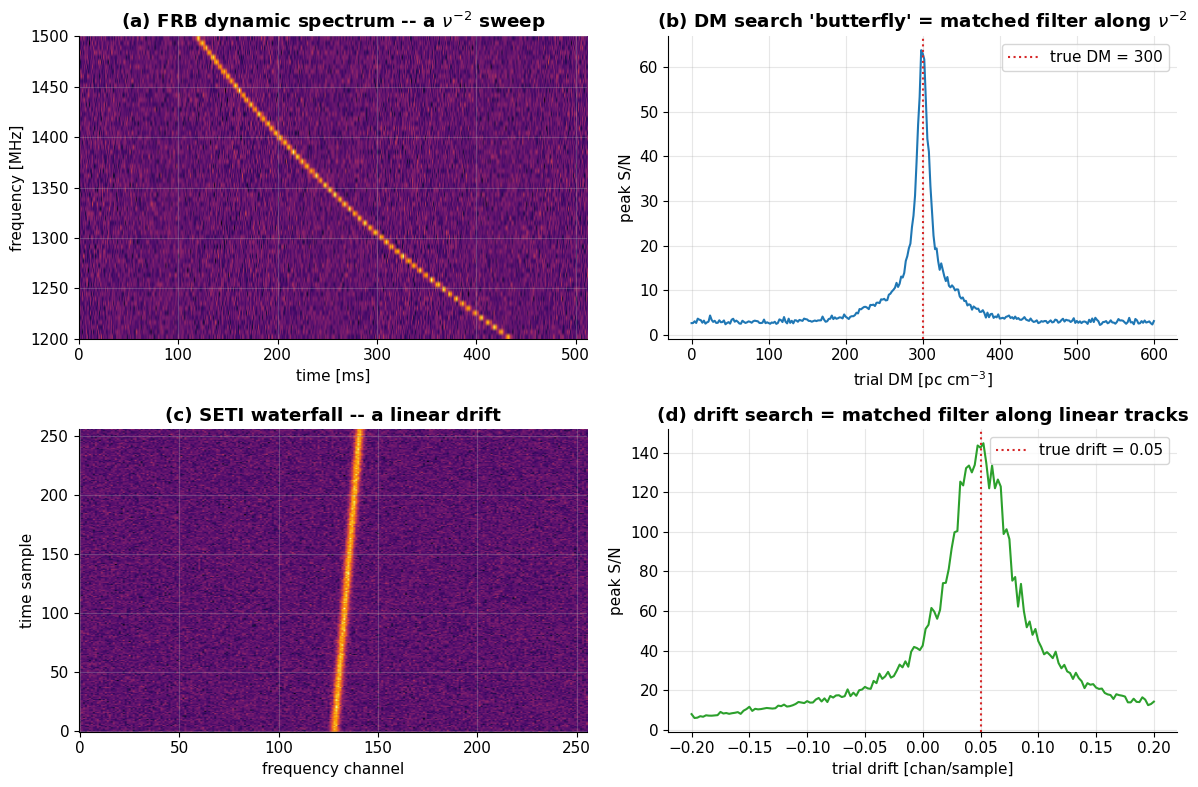

DM search    : best DM    = 298.0 (true 300), S/N = 63.8
Drift search : best drift = 0.052 (true 0.05), S/N = 144.7


In [6]:
# --- (a) FRB dedispersion: matched filtering along nu^-2 tracks (Ch 18) -------
n_time, dt = 512, 0.001                       # s
freqs = np.linspace(1200, 1500, 64)           # MHz
DM_true = 300.0
dynspec = disperse_pulse(n_time, freqs, dm=DM_true, dt=dt,
                         t0_index=120, width_samples=2.0, amplitude=8.0, seed=1)

dm_trials = np.linspace(0, 600, 301)
dm_res = dm_search(dynspec, freqs, dt, dm_trials)

# --- (b) SETI drift search: matched filtering along linear tracks (Ch 21) -----
drift_true = 0.05                              # channels per time sample
waterfall = drifting_tone(256, 256, drift_rate=drift_true, snr=10.0, seed=2)

drift_trials = np.linspace(-0.2, 0.2, 161)
dr_res = drift_search(waterfall, drift_trials)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(dynspec.T, aspect="auto", origin="lower",
                  extent=[0, n_time * dt * 1e3, freqs[0], freqs[-1]])
axes[0, 0].set_title(r"(a) FRB dynamic spectrum -- a $\nu^{-2}$ sweep")
axes[0, 0].set_xlabel("time [ms]"); axes[0, 0].set_ylabel("frequency [MHz]")

axes[0, 1].plot(dm_res.dms, dm_res.snr, color="#1f77b4")
axes[0, 1].axvline(DM_true, color="#d62728", ls=":", label=f"true DM = {DM_true:.0f}")
axes[0, 1].set_title(r"(b) DM search 'butterfly' = matched filter along $\nu^{-2}$")
axes[0, 1].set_xlabel("trial DM [pc cm$^{-3}$]"); axes[0, 1].set_ylabel("peak S/N")
axes[0, 1].legend()

axes[1, 0].imshow(waterfall, aspect="auto", origin="lower")
axes[1, 0].set_title("(c) SETI waterfall -- a linear drift")
axes[1, 0].set_xlabel("frequency channel"); axes[1, 0].set_ylabel("time sample")

axes[1, 1].plot(dr_res.drift_rates, dr_res.snr, color="#2ca02c")
axes[1, 1].axvline(drift_true, color="#d62728", ls=":", label=f"true drift = {drift_true}")
axes[1, 1].set_title("(d) drift search = matched filter along linear tracks")
axes[1, 1].set_xlabel("trial drift [chan/sample]"); axes[1, 1].set_ylabel("peak S/N")
axes[1, 1].legend()

fig.tight_layout(); plt.show()

print(f"DM search    : best DM    = {dm_res.best_dm:.1f} (true {DM_true:.0f}), S/N = {dm_res.best_snr:.1f}")
print(f"Drift search : best drift = {dr_res.best_drift:.3f} (true {drift_true}), S/N = {dr_res.best_snr:.1f}")

Panels (b) and (d) are the **same plot**: a matched-filter response that peaks
sharply when the trial track matches the signal's track and falls away on either
side. One is parametrised by a dispersion measure (a $\nu^{-2}$ curve), the other
by a drift rate (a straight line) — but the machinery (shift-and-sum along a trial
template, keep the peak) is identical. *Dedispersion and de-drifting are matched
filtering.* Once you see this, every transient and technosignature search in the
course is one idea.

## 5. ROC curves & thresholds — how sure is "sure"?

The matched filter gives us the best **statistic** $T$. Section 1's second
question remains: where do we put the **threshold** $\gamma$? Every choice trades
off two kinds of mistake:

- a **false alarm** (false positive): noise alone produces $T>\gamma$ — we cry
  wolf. Its rate is the **probability of false alarm**, $P_\text{FA}$.
- a **miss** (false negative): a real signal fails to clear $\gamma$. We quote the
  complement, the **probability of detection**, $P_\text{D}$.

Lower the threshold and you catch more real signals (good, $P_\text{D}\uparrow$)
but also more noise (bad, $P_\text{FA}\uparrow$). The curve traced by
$(P_\text{FA}, P_\text{D})$ as $\gamma$ sweeps is the **receiver operating
characteristic (ROC)** — the term is a literal inheritance from WWII radar
operators. A better detector, or a stronger signal, bows the ROC up toward the
top-left corner (high detection, low false alarm). Let us measure one by Monte
Carlo.

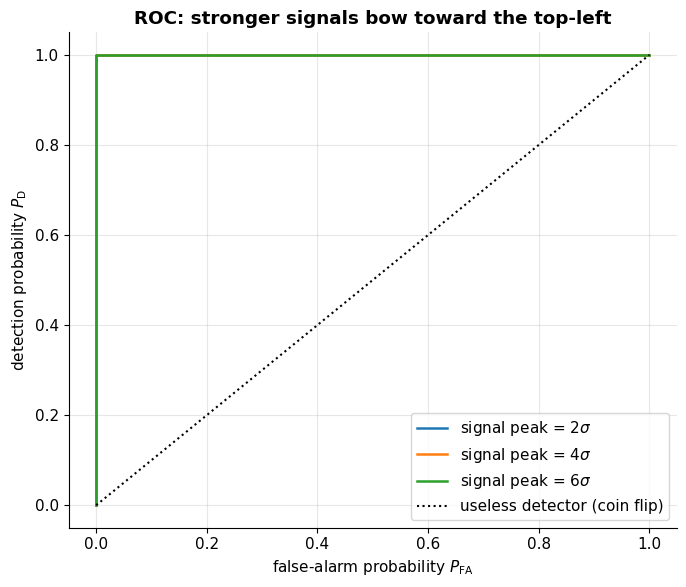

In [7]:
# Monte Carlo ROC: run the matched filter on many noise-only and many signal+noise
# realisations, then sweep the threshold.
n_mc = 4000
templ_u = template / np.linalg.norm(template)   # unit-norm template

def mf_peak_stat(d):
    # Peak of the matched-filter output -- our detection statistic T.
    return np.correlate(d, templ_u, mode="same").max()

def roc_for_amplitude(a_sig):
    T_noise = np.array([mf_peak_stat(rng.normal(0, 1.0, N)) for _ in range(n_mc)])
    T_sig   = np.array([mf_peak_stat(a_sig * template + rng.normal(0, 1.0, N))
                        for _ in range(n_mc)])
    gammas = np.linspace(0, max(T_noise.max(), T_sig.max()), 300)
    pfa = np.array([(T_noise > g).mean() for g in gammas])
    pd  = np.array([(T_sig   > g).mean() for g in gammas])
    return pfa, pd, gammas

fig, ax = plt.subplots(figsize=(7, 6))
for a_sig, col in [(2.0, "#1f77b4"), (4.0, "#ff7f0e"), (6.0, "#2ca02c")]:
    pfa, pd, _ = roc_for_amplitude(a_sig)
    ax.plot(pfa, pd, color=col, lw=1.8, label=f"signal peak = {a_sig:.0f}$\\sigma$")
ax.plot([0, 1], [0, 1], "k:", label="useless detector (coin flip)")
ax.set_xlabel(r"false-alarm probability $P_{\rm FA}$")
ax.set_ylabel(r"detection probability $P_{\rm D}$")
ax.set_title("ROC: stronger signals bow toward the top-left")
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

A stronger signal pushes the ROC toward the ideal top-left corner: you can have a
high detection probability *and* a low false-alarm rate at once. A weak signal
hugs the diagonal — the "useless detector" where you only do as well as a coin
flip. The detector's job is to bow that curve up; the matched filter bows it as
far as the noise allows.

### The "5σ" convention and the trials factor

Astronomers traditionally demand a **$5\sigma$** detection. Why so strict? For a
single Gaussian test, a threshold at $5\sigma$ gives a false-alarm probability of

$$
P_\text{FA} = \tfrac12\,\operatorname{erfc}\!\left(\frac{5}{\sqrt2}\right)
\approx 2.9\times10^{-7},
$$

about one in 3.5 million. That sounds like absurd overkill — until you remember
how **many tests** a real search runs. A pipeline tries thousands of DMs, hundreds
of drift rates, a dozen boxcar widths, across millions of time samples and many
sky pointings. Each trial is another roll of the dice, another chance for noise to
clear the bar. This is the **trials factor** (the "look-elsewhere effect"): if you
make $M$ independent tests, the probability that *at least one* noise trial exceeds
the threshold is

$$
P_\text{FA}^\text{(total)} \approx 1 - (1 - P_\text{FA})^{M} \approx M\,P_\text{FA}
\quad(\text{for small } P_\text{FA}).
$$

So **many trials → you must raise the threshold** to keep the overall false-alarm
rate under control. Let us make that concrete.

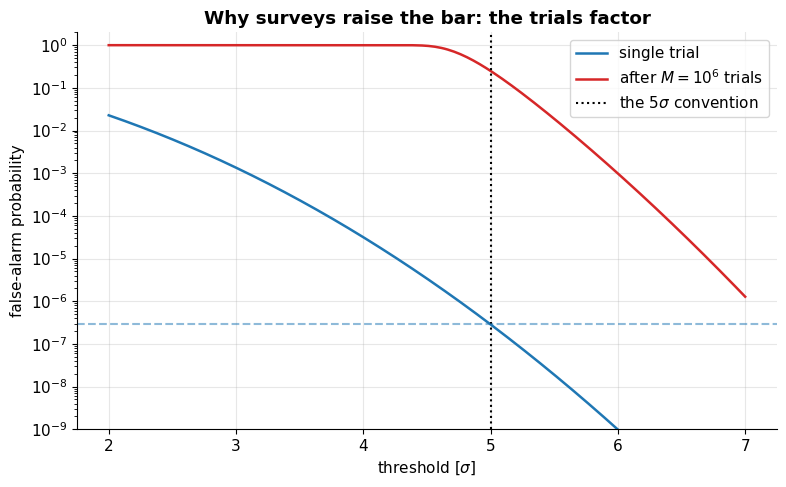

Single-trial 5-sigma false-alarm prob : 2.87e-07  (~1 in 3.49e+06)
After 1e+06 trials, a 5-sigma bar fires by chance with prob 0.249
To keep the *survey* at the 5-sigma level you must threshold at 7.21 sigma instead.


In [8]:
# Single-trial false-alarm probability vs threshold, and what the trials factor does.
sig_levels = np.linspace(2, 7, 200)
pfa_single = 0.5 * special.erfc(sig_levels / np.sqrt(2))

M = 1_000_000   # a modest survey: e.g. 3000 DMs x 300 widths-ish worth of trials
pfa_survey = 1 - (1 - pfa_single) ** M

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(sig_levels, pfa_single, color="#1f77b4", lw=1.8, label="single trial")
ax.semilogy(sig_levels, pfa_survey, color="#d62728", lw=1.8,
            label=f"after $M=10^{{{int(np.log10(M))}}}$ trials")
ax.axvline(5.0, color="k", ls=":", label=r"the $5\sigma$ convention")
ax.axhline(2.9e-7, color="#1f77b4", ls="--", alpha=0.5)
ax.set_xlabel(r"threshold [$\sigma$]")
ax.set_ylabel("false-alarm probability")
ax.set_title("Why surveys raise the bar: the trials factor")
ax.set_ylim(1e-9, 2); ax.legend()
fig.tight_layout(); plt.show()

p5 = 0.5 * special.erfc(5 / np.sqrt(2))
# threshold needed to keep the SURVEY false-alarm at the single-trial 5-sigma level:
target = p5
sig_needed = np.sqrt(2) * special.erfcinv(2 * target / M)
print(f"Single-trial 5-sigma false-alarm prob : {p5:.2e}  (~1 in {1/p5:.2e})")
print(f"After {M:.0e} trials, a 5-sigma bar fires by chance with prob {1-(1-p5)**M:.3f}")
print(f"To keep the *survey* at the 5-sigma level you must threshold at "
      f"{sig_needed:.2f} sigma instead.")

The red curve is the lesson: a bar that is rock-solid for **one** test (the blue
$5\sigma$ line, one-in-millions) is nearly *guaranteed* to fire by chance once you
run a million trials. To hold the **survey-wide** false-alarm rate at $5\sigma$,
you must raise the per-trial threshold (here to $\sim5.9\sigma$). This is why
single-pulse and SETI pipelines quote thresholds well above $5\sigma$ and still
follow up *every* candidate with the RFI/cadence discipline of Chapters 18 and 21.
A high statistic is necessary but never sufficient — you also have to ask how many
chances noise had to fake it.

## 6. Try it yourself

### Exercise 1 — Push the matched filter to its limit
Lower `amp_true` in Section 1 (try 0.8, 0.5, 0.3) and re-run the matched filter.
How small can the per-sample amplitude get before the matched-filter peak no
longer stands clearly above the noise? Relate your answer to the
$\sqrt{N_\text{pulse}}$ gain — given this pulse's width, what peak S/N do you
expect, and does the experiment agree?

In [9]:
# Exercise 1 starter -- sweep the true amplitude and watch the matched-filter peak.
# Average over realisations so the measured peak tracks the (a/sigma)*||s|| prediction;
# a single realisation is biased upward by the ~3-sigma noise floor of the filter output.
u = template / np.linalg.norm(template)
for amp in [0.8, 0.5, 0.3]:
    peaks = [np.correlate(amp * template + rng.normal(0, 1.0, N), u, mode="same").max()
             for _ in range(200)]
    expected = amp * np.linalg.norm(template)        # (a/sigma)*||s||, sigma=1
    print(f"amp={amp:.1f}:  mean MF peak = {np.mean(peaks):5.2f},  signal term ~ {expected:5.2f}  "
          f"(noise-only peaks ~ 3 sigma)")
# TODO: at what amplitude does the signal term sink into the ~3-sigma noise floor of the filter?

amp=0.8:  mean MF peak =  3.95,  signal term ~  3.69  (noise-only peaks ~ 3 sigma)
amp=0.5:  mean MF peak =  2.87,  signal term ~  2.31  (noise-only peaks ~ 3 sigma)
amp=0.3:  mean MF peak =  2.29,  signal term ~  1.38  (noise-only peaks ~ 3 sigma)


<details><summary>Solution</summary>

The matched-filter signal term is $(a/\sigma)\,\lVert\mathbf{s}\rVert$, while the filter's noise-only output peaks at $\approx 3\sigma$ (the largest of $N$ correlated samples). The pulse stays clearly visible while the signal term sits comfortably above that $\sim 3\sigma$ floor; it sinks into the noise when $(a/\sigma)\,\lVert\mathbf{s}\rVert \lesssim 3$, i.e. once $a \lesssim 3 / \lVert\mathbf{s}\rVert$.

```python
u = template / np.linalg.norm(template)
norm_s = np.linalg.norm(template)          # ||s||, sigma = 1
print(f"||s|| = {norm_s:.2f}  ->  signal term = a * {norm_s:.2f}")
print(f"Pulse fades when signal term ~ 3-sigma floor, i.e. a ~ {3/norm_s:.2f}\n")

for amp in [0.8, 0.5, 0.3, 0.2]:
    peaks = [np.correlate(amp * template + rng.normal(0, 1.0, N), u, mode="same").max()
             for _ in range(200)]
    expected = amp * norm_s
    verdict = "clear" if expected > 3 else "lost in noise floor"
    print(f"amp={amp:.1f}:  mean MF peak = {np.mean(peaks):5.2f},  "
          f"signal term ~ {expected:5.2f}  ({verdict})")
```

Here $\lVert\mathbf{s}\rVert \approx 5.5$ (a Gaussian of `width=12` over 512 samples), so the threshold is $a \approx 3/5.5 \approx 0.55$. Down to `amp=0.8` and `amp=0.5` the peak still beats the noise floor; by `amp\approx 0.3` (signal term $\approx 1.4$) the pulse is buried. Key takeaway: matched filtering converts a sub-noise per-sample amplitude into a confident detection only while $(a/\sigma)\sqrt{N_\text{pulse}}$ clears the $\sim 3\sigma$ output floor — the $\sqrt{N}$ gain prediction agrees with the experiment.

</details>

### Exercise 2 — A boxcar bank on a wider pulse
Make a pulse with `pulse_width = 16.0` (much broader) in Section 3 and re-run the
boxcar sweep. Does the best width move? Confirm it tracks the FWHM
($\approx 2.355\,\sigma$), and explain in one sentence why a single fixed-width
boxcar is a poor FRB detector.

In [10]:
# Exercise 2 starter -- change the width and find the best boxcar.
pulse_width_ex = 16.0   # TODO: try 4, 10, 16, 25
series_ex = np.exp(-0.5 * ((t - centre) / pulse_width_ex) ** 2) + rng.normal(0, 1.0, N)
best_snr_ex, best_w_ex, _ = boxcar_snr(series_ex, trial_widths)
print(f"pulse FWHM ~ {2.355*pulse_width_ex:.0f} samples -> best boxcar width = {best_w_ex}, S/N = {best_snr_ex:.1f}")

pulse FWHM ~ 38 samples -> best boxcar width = 16, S/N = 4.0


<details><summary>Solution</summary>

Sweep the pulse width and let `boxcar_snr` pick the best boxcar from the same `trial_widths` bank. The best width tracks the pulse FWHM ($\approx 2.355\,\sigma$), snapping to the nearest available trial width — so as the pulse broadens, the winning boxcar grows with it.

```python
for pw in [4.0, 10.0, 16.0, 25.0]:
    series_ex = np.exp(-0.5 * ((t - centre) / pw) ** 2) + rng.normal(0, 1.0, N)
    best_snr_ex, best_w_ex, _ = boxcar_snr(series_ex, trial_widths)
    print(f"sigma={pw:4.1f}  FWHM ~ {2.355*pw:4.0f} samples  ->  "
          f"best boxcar width = {best_w_ex:2d}, S/N = {best_snr_ex:.1f}")
```

The best width climbs as the pulse widens (the optimum is the trial width nearest the FWHM, capped by the largest width in the bank). One sentence on why a single fixed-width boxcar is a poor FRB detector: FRB widths span orders of magnitude and are unknown in advance, so a fixed boxcar is matched to only one of them and throws away S/N (too narrow integrates part of the pulse, too wide folds in pure noise) for every other — which is exactly why pipelines run a *bank* of widths and keep the best.

</details>

### Exercise 3 — Your own trials factor
Suppose your survey runs $3000$ trial DMs $\times$ $12$ boxcar widths $\times$
$10^6$ time samples. Compute the total number of (roughly independent) trials, and
find the per-trial threshold in $\sigma$ that keeps the **survey-wide** false-alarm
probability at $0.01$. Is it above or below $5\sigma$?

In [11]:
# Exercise 3 starter -- solve for the threshold given a trials budget.
M_ex = 3000 * 12 * 1_000_000          # TODO: adjust to your own survey design
target_survey_pfa = 0.01
per_trial = 1 - (1 - target_survey_pfa) ** (1 / M_ex)
sig_needed_ex = np.sqrt(2) * special.erfcinv(2 * per_trial)
print(f"Total trials M = {M_ex:.2e}")
print(f"Per-trial threshold for survey P_FA={target_survey_pfa}: {sig_needed_ex:.2f} sigma")

Total trials M = 3.60e+10
Per-trial threshold for survey P_FA=0.01: 7.21 sigma


<details><summary>Solution</summary>

Multiply the trial counts to get the total budget $M$, then invert the trials-factor relation $P_\text{FA}^\text{(total)} = 1-(1-P_\text{FA})^M$ for the per-trial $P_\text{FA}$, and convert that to a $\sigma$ threshold with `special.erfcinv` (the same inversion used in Section 5).

```python
M_ex = 3000 * 12 * 1_000_000               # DMs x widths x time samples
target_survey_pfa = 0.01
per_trial = 1 - (1 - target_survey_pfa) ** (1 / M_ex)
sig_needed_ex = np.sqrt(2) * special.erfcinv(2 * per_trial)
print(f"Total trials M = {M_ex:.2e}")
print(f"Per-trial P_FA  = {per_trial:.2e}")
print(f"Per-trial threshold for survey P_FA={target_survey_pfa}: {sig_needed_ex:.2f} sigma")
print(f"-> {'above' if sig_needed_ex > 5 else 'below'} the 5-sigma convention")
```

The budget is $M = 3000 \times 12 \times 10^6 = 3.6\times10^{10}$ trials, which forces a per-trial threshold of $\approx 7.2\sigma$ — well **above** $5\sigma$. Key takeaway: with tens of billions of rolls of the dice, even a one-in-millions single-trial bar is far too low; the look-elsewhere effect is why real single-pulse and SETI searches threshold well above $5\sigma$ and still vet every candidate.

</details>

## Recap

- Detection is a **decision between two hypotheses** — noise only ($H_0$) versus
  signal-plus-noise ($H_1$) — made by comparing a **statistic** to a **threshold**.
- The **matched filter** is the optimal *linear* statistic in white Gaussian
  noise: correlate the data with a copy of the known template, $T=\mathbf{s}\cdot
  \mathbf{x}$. The one-line proof is Cauchy–Schwarz; pointing the filter off the
  signal only loses S/N.
- Its peak S/N is $(a/\sigma)\,|\mathbf{s}| = (a/\sigma)\sqrt{N_\text{pulse}}$ for a
  top-hat pulse — the **$\sqrt{N}$ gain** that turns a buried pulse into a
  confident detection, the same $1/\sqrt{N}$ averaging law of *Maths Prelims* §5.
- A **boxcar bank** (`jansky.transients.boxcar_snr`) handles the unknown width: the
  boxcar matched to the pulse FWHM maximises S/N — the FRB width search of Ch 18.
- **Dedispersion** (`dm_search`, along $\nu^{-2}$ tracks) and the **Doppler-drift
  search** (`drift_search`, along linear tracks) are the *same* matched filter,
  applied along a trial curve. The DM "butterfly" and the drift S/N curve are one
  plot. **One unifying idea.**
- The **ROC curve** trades detection against false alarm; the **"5σ"** convention
  buys a one-in-millions single-trial false alarm, but the **trials factor**
  (look-elsewhere) means many trials force the threshold *higher* still.

### What's next

- **[Chapter 18 — Fast Radio Bursts](18_fast_radio_bursts.ipynb)** is where the
  boxcar and DM searches of Sections 3–4 do real work: a single-pulse search with
  the same `dm_search` "butterfly," plus the RFI discipline that a high statistic
  alone can never replace.
- **[Chapter 21 — SETI](21_seti.ipynb)** applies the identical machinery along
  drift tracks, then adds the ON/OFF **cadence** test — the practical answer to
  the trials-factor problem of Section 5.
- For the maths underneath, keep
  [*Mathematical Preliminaries* §5 and §8](../docs/math-preliminaries.md) at hand.